# 04. SEOF Forecast Model

Build the monthly projection scores and lag-weight forecast model from the training period.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

REPO_ROOT = Path("..").resolve()
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eams_seof.config import load_config, resolve_path

CONFIG_PATH = REPO_ROOT / "configs" / "manuscript.yml"
cfg = load_config(CONFIG_PATH, repo_root=REPO_ROOT)

print("Repository:", REPO_ROOT)
print("Config:", CONFIG_PATH)


Repository: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_v1
Config: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_v1/configs/manuscript.yml


In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from eams_seof.preprocessing import detrend_anomaly
from eams_seof.seof import project_seof
from eams_seof.lag_weights import lag_weights
from eams_seof.io import save_dataset

sst_path = resolve_path(REPO_ROOT, cfg["paths"]["oisst_smoothed"])
decomp_path = resolve_path(REPO_ROOT, cfg["paths"]["seof_model"])
forecast_model_path = resolve_path(REPO_ROOT, cfg["paths"]["forecast_model"])

sst = xr.open_dataset(sst_path)["sst"].sel(
    lat=slice(*cfg["domain"]["latitude"]),
    lon=slice(*cfg["domain"]["longitude"]),
)

decomp = xr.open_dataset(decomp_path)
aligned_patterns = decomp["aligned_eof_patterns"]
seof_mean = decomp["seof_mean"]

sea_mask = np.isfinite(sst).any("time")
training_period = tuple(cfg["periods"]["training"])

(
    detrended_sst,
    _,
    _,
    _,
) = detrend_anomaly(
    sst,
    training_period=training_period,
    sea_mask=sea_mask,
)


## Monthly pattern-projection scores

Project monthly SST anomalies onto the aligned SEOF patterns.

<xarray.DataArray 'monthly_projection_score' (time: 403, mode: 3)>
array([[ -6.184948 , -13.774804 ,   5.8530736],
       [-22.018278 , -10.509062 , -12.134491 ],
       [-26.797035 ,   1.3144543,  -7.6277275],
       ...,
       [ 61.385715 , -56.691826 ,  30.779943 ],
       [ 61.87964  , -53.4392   , -13.254303 ],
       [ 77.86395  , -57.707516 ,  12.274743 ]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1993-01-01 1993-02-01 ... 2026-07-01
  * mode     (mode) int64 1 2 3

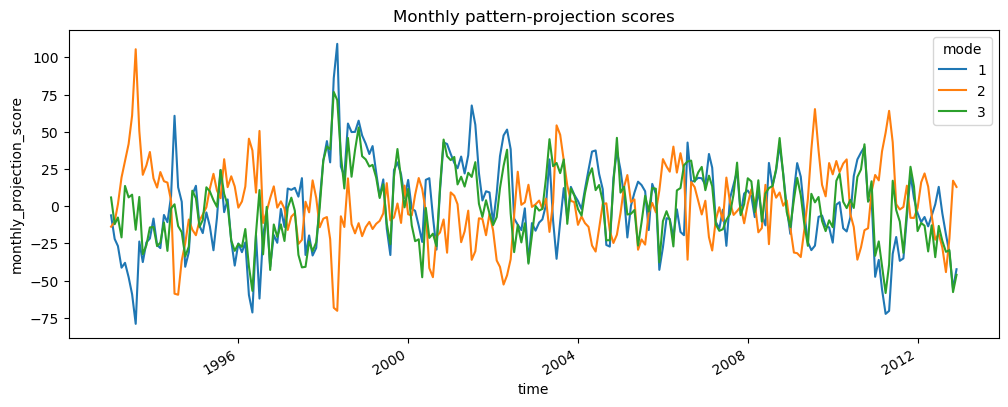

In [3]:
monthly_scores = project_seof(
    detrended_sst,
    aligned_patterns,
    seof_mean,
)

display(monthly_scores)

monthly_scores.sel(
    time=slice("1993-01-01", "2012-12-31")
).plot.line(x="time", hue="mode", figsize=(12, 4))

plt.title("Monthly pattern-projection scores")
plt.show()


## Lead- and target-month-dependent lag weights

Inspect the lag-weight kernels used by the forecast model.

In [4]:
lag_model = lag_weights(
    monthly_scores=monthly_scores,
    training_period=training_period,
    maximum_lead_months=int(
        cfg["forecast"]["maximum_lead_months"]
    ),
    input_sequence_months=int(
        cfg["forecast"]["input_sequence_months"]
    ),
    shrinkage_pseudocount=int(
        cfg["forecast"]["shrinkage_pseudocount"]
    ),
    polarity_method=cfg["forecast"][
        "lag_polarity_regularization"
    ],
)

lag_weight = lag_model["lag_weight"]

display(lag_model)

print("Max |sum(|w|)-1|:")
print(
    float(
        np.abs(
            np.abs(lag_weight).sum("lag") - 1.0
        ).max()
    )
)


<xarray.Dataset>
Dimensions:                          (mode: 3, month: 12, lead: 13, lag: 12)
Coordinates:
  * mode                             (mode) int64 1 2 3
  * month                            (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * lead                             (lead) int64 0 1 2 3 4 5 6 7 8 9 10 11 12
  * lag                              (lag) int64 0 1 2 3 4 5 6 7 8 9 10 11
Data variables:
    lag_weight                       (mode, month, lead, lag) float32 0.2709 ...
    pooled_lag_correlation           (mode, lead, lag) float32 1.0 ... -0.05461
    target_month_lag_correlation     (mode, month, lead, lag) float32 1.0 ......
    training_sample_count            (mode, month, lead) int32 19 19 ... 19 19
    target_month_shrinkage_fraction  (mode, month, lead) float32 0.4419 ... 0...
Attributes:
    polarity_regularization:  lag0_nonnegative
    shrinkage_pseudocount:    24
    input_sequence_months:    12
    maximum_lead_months:      12

Max |sum(|w|)-1|:
2.384185791015625e-07


## Save the forecast model


In [5]:
forecast_model = xr.Dataset(
    {
        "monthly_projection_score": monthly_scores,
        "lag_weight": lag_model["lag_weight"],
        "pooled_lag_correlation": lag_model[
            "pooled_lag_correlation"
        ],
        "target_month_lag_correlation": lag_model[
            "target_month_lag_correlation"
        ],
        "training_sample_count": lag_model[
            "training_sample_count"
        ],
        "target_month_shrinkage_fraction": lag_model[
            "target_month_shrinkage_fraction"
        ],
    },
    attrs={
        "training_start": training_period[0],
        "training_end": training_period[1],
        "input_sequence_months": int(
            cfg["forecast"]["input_sequence_months"]
        ),
        "maximum_lead_months": int(
            cfg["forecast"]["maximum_lead_months"]
        ),
        "lag_polarity_regularization": cfg[
            "forecast"
        ]["lag_polarity_regularization"],
        "shrinkage_pseudocount": int(
            cfg["forecast"]["shrinkage_pseudocount"]
        ),
    },
)

save_dataset(forecast_model, forecast_model_path)

print("Saved:", forecast_model_path)


Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_v1/outputs/model/forecast_model.nc


## Inspect one component / target month

Visualize one lag-weight kernel.

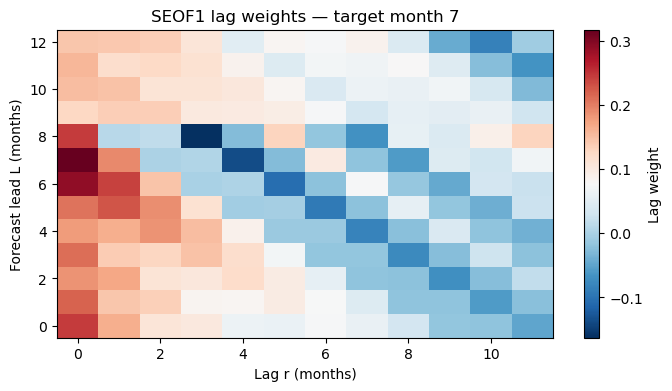

In [6]:
example_mode = 1
example_month = 7

example = lag_weight.sel(
    mode=example_mode,
    month=example_month,
)

fig, ax = plt.subplots(figsize=(8, 4))
mesh = ax.pcolormesh(
    example.lag,
    example.lead,
    example,
    cmap="RdBu_r",
    shading="auto",
)
ax.set_xlabel("Lag r (months)")
ax.set_ylabel("Forecast lead L (months)")
ax.set_title(
    f"SEOF{example_mode} lag weights — target month {example_month}"
)
fig.colorbar(mesh, ax=ax, label="Lag weight")
plt.show()
